In [3]:
print("Hello from my ML project!")

import sys
import platform

print(sys.version)
print(platform.python_version())
print(sys.executable)

import ipykernel
print(ipykernel.__version__)

Hello from my ML project!
3.13.14 (main, Jun 23 2026, 15:19:27) [MSC v.1944 64 bit (AMD64)]
3.13.14
c:\Users\LENOVO\Desktop\E2E-Heart-Disease-Prediction\.venv\Scripts\python.exe
7.3.0


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [6]:
df = pd.read_csv("../notebooks/Data/heart.csv")

In [7]:
df.sample(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
680,42,1,1,120,295,0,1,162,0,0.0,2,0,2,1
594,64,1,0,145,212,0,0,132,0,2.0,1,2,1,0
471,64,0,2,140,313,0,1,133,0,0.2,2,0,3,1
997,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0
322,45,1,0,142,309,0,0,147,1,0.0,1,3,3,0


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [9]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [11]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(723)

In [15]:
df.shape

(1025, 14)

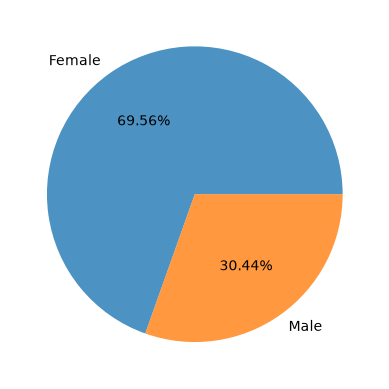

In [ ]:
plt.pie(df['sex'].value_counts(), labels=['Female', 'Male'], autopct='%.2f%%', wedgeprops=dict(alpha=0.8))
plt.show()

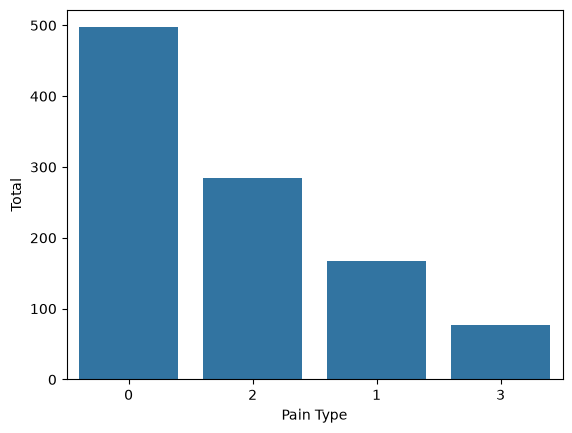

In [ ]:
sns.countplot(x='cp', data=df, order=df['cp'].value_counts().index)
plt.xlabel('Pain Type')
plt.ylabel('Total')
plt.show()

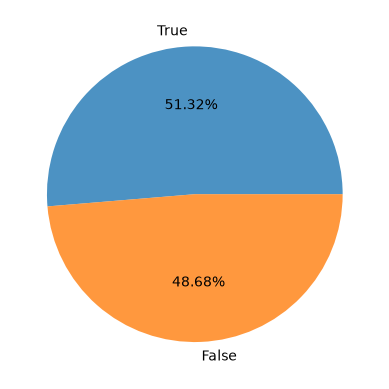

In [18]:
plt.pie(df['target'].value_counts(), labels=['True', 'False'], autopct='%.2f%%', wedgeprops=dict(alpha=0.8))
plt.show()

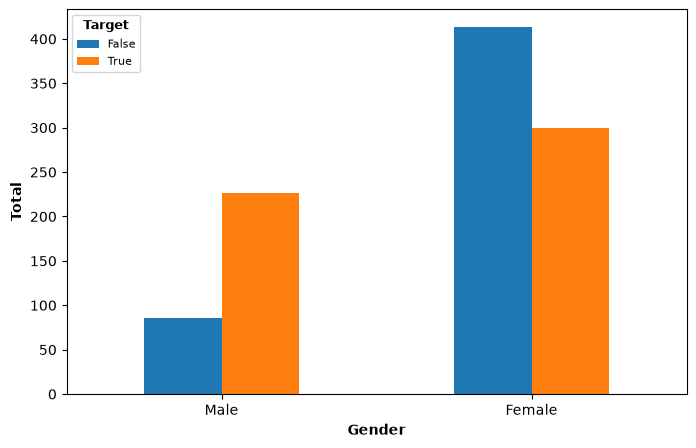

In [20]:
labels = ['False', 'True']
label_gender = np.array([0, 1])
label_gender2 = ['Male', 'Female']
ax = pd.crosstab(df.sex, df.target).plot(kind='bar', figsize=(8, 5))
plt.xlabel('Gender', fontfamily='sans-serif', fontweight='bold')
plt.ylabel('Total', fontfamily='sans-serif', fontweight='bold')
plt.xticks(label_gender, label_gender2, rotation=0)
plt.legend(labels=labels, title='$\\bf{Target}$', fontsize='8', title_fontsize='9', loc='upper left', frameon=True)
plt.show()

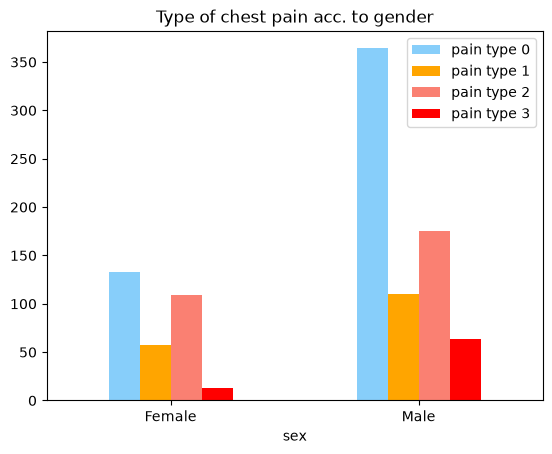

In [22]:
fig = pd.crosstab(df.sex, df.cp).plot(kind = 'bar', color = ['lightskyblue', 'orange', 'salmon', 'red'])
fig.set_xticklabels(labels=['Female', 'Male'], rotation=0)
plt.title('Type of chest pain acc. to gender')
plt.legend(['pain type 0', 'pain type 1', 'pain type 2', 'pain type 3'])
plt.show()

In [23]:
df["target"].value_counts()

target
1    526
0    499
Name: count, dtype: int64

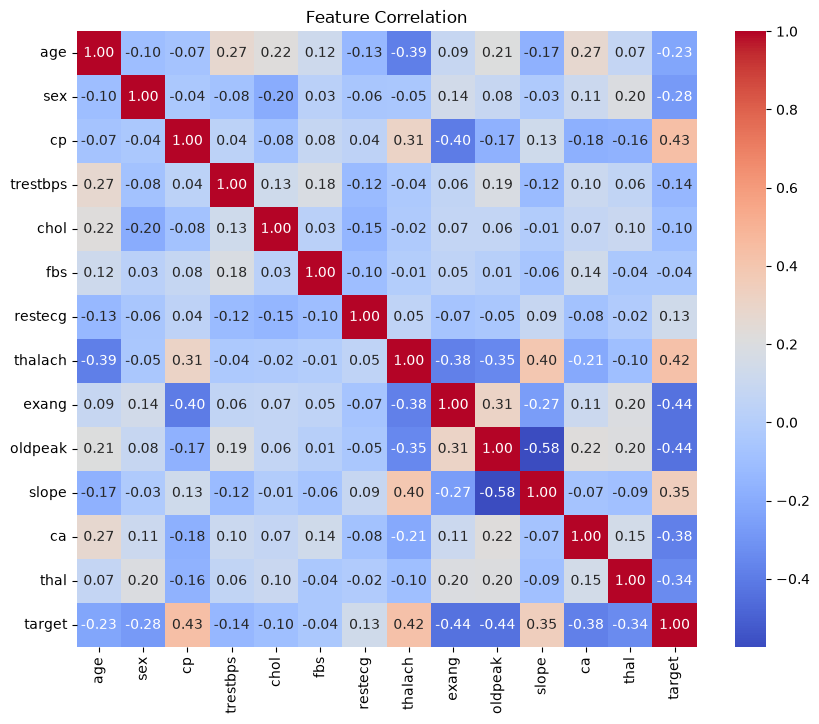

In [25]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

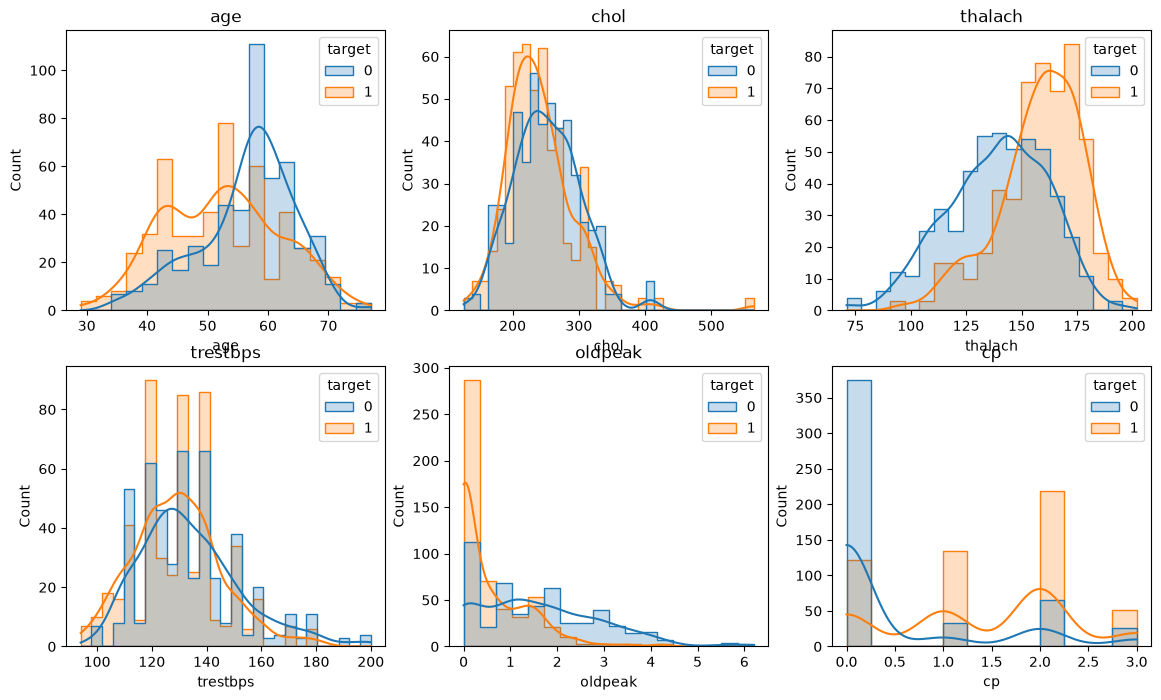

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, ["age", "chol", "thalach", "trestbps", "oldpeak", "cp"]):
    sns.histplot(data=df, x=col, hue="target", kde=True, ax=ax, element="step")
    ax.set_title(col)
plt.show()